# Linear cavity design

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import abcd

### Concave concave

In [2]:
array_length = np.linspace(0, 300, int(1e3)) * 1e-3   # m

R1 = 100e-3
R2 = 100e-3
wavelength = 780e-9   # m

ABCD_array_waist, _, ABCD_array_stability_values = abcd.concave_concave( R1, R2, array_length, wavelength, d= 10e-3, n=1.816 )

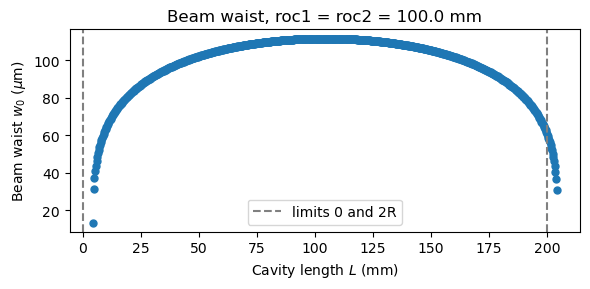

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(array_length[ABCD_array_stability_values] * 1e3, ABCD_array_waist * 1e6,'o', markersize=5,)
ax.set_xlabel(r'Cavity length $L$ (mm)')
ax.set_ylabel(r'Beam waist $w_0$ ($\mu$m)')
ax.set_title(rf'Beam waist, roc1 = roc2 = {R2*1e3:.1f} mm')

# limits 0 and 2R
ax.axvline(0, linestyle='--', c="gray", label = "limits 0 and 2R")
ax.axvline(2 * 100, linestyle='--', c="gray")  # if L is in meters
ax.legend()

plt.tight_layout()
plt.show()

Comparaison avec Kogelnik

In [4]:
array_length = np.linspace(0, 500, int(1e3)) * 1e-3   # m

R1 = 100e-3
R2 = 150e-3
wavelength = 780e-9   # m

# ABCD starting from mirror
ABCD_array_waist, _, ABCD_array_stability_values = abcd.concave_concave( R1, R2, array_length, wavelength, d= 0, n=1.816  )

# Kogelnik
Kogelnik_array_stability_values = abcd.kogelnik_stability_values( R1, R2, array_length)
Kogelnik_array_waist = abcd.kogelnik_waist_concave_concave(R1, R2, array_length[Kogelnik_array_stability_values], wavelength)

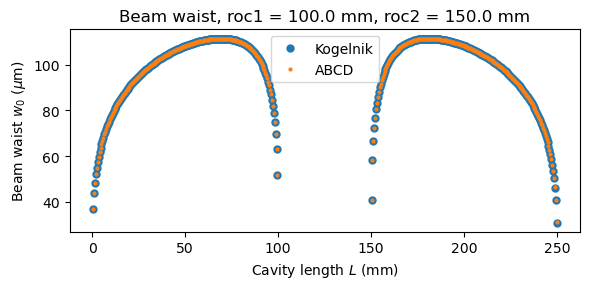

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(array_length[Kogelnik_array_stability_values] * 1e3, Kogelnik_array_waist * 1e6,'o', markersize=5,label = "Kogelnik")
ax.plot(array_length[ABCD_array_stability_values] * 1e3, ABCD_array_waist * 1e6,'o', markersize=2, label = "ABCD")

ax.set_xlabel(r'Cavity length $L$ (mm)')
ax.set_ylabel(r'Beam waist $w_0$ ($\mu$m)')
ax.set_title(rf'Beam waist, roc1 = {R1*1e3:.1f} mm, roc2 = {R2*1e3:.1f} mm')
ax.legend()
#plt.ylim(0 , 200)
plt.tight_layout()
plt.show()

Verification on an experimental setup \\

Papier de Mehmet et al 2011 : Squeezed light at 1550 nm with a quantum noise reduction of 12.3 dB at 20mm between the mirrors w0 = 60 micro m
https://opg.optica.org/directpdfaccess/db3a84e1-a135-4ba3-aaff068d20dad29e_225591/oe-19-25-25763.pdf?da=1&id=225591&seq=0&mobile=no



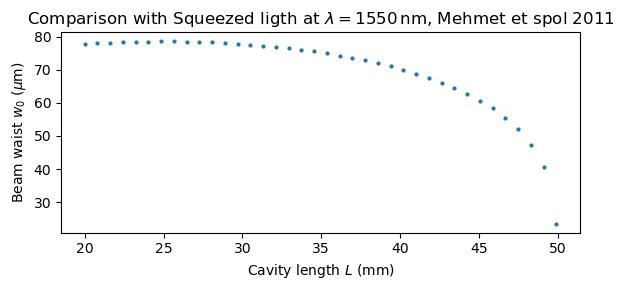

In [18]:
array_length = np.linspace(20, 100, 100) * 1e-3   # m
R1 = 25e-3
R2 = 25e-3
wavelength = 2 * 775e-9   # m

ABCD_array_waist, _, ABCD_array_stability_values = abcd.concave_concave(R1,R2,array_length,wavelength, d=0)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(array_length[ABCD_array_stability_values] * 1e3, ABCD_array_waist * 1e6,'o', markersize=2,)
ax.set_xlabel(r'Cavity length $L$ (mm)')
ax.set_ylabel(r'Beam waist $w_0$ ($\mu$m)')
ax.set_title(rf'Comparison with Squeezed ligth at $\lambda = {wavelength*1e9:.0f}\,$nm, Mehmet et spol 2011')
#ax.legend()
plt.tight_layout()
plt.show()

### Plan concave

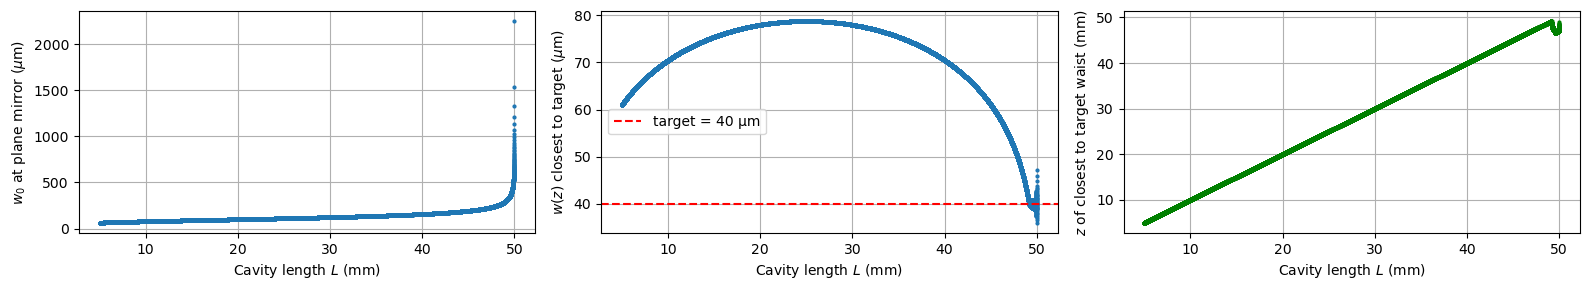

In [10]:
R1 = 50e-3   # radius of curvature concave mirror
wavelength = 780e-9     # m
wz_target = 40e-6   # 40 µm target waist

array_length = np.linspace(5e-3, 60e-3, 50000)

waist_values, stability_values, wz_close, z_close, _, _ = abcd.plan_concave(R1, array_length, wavelength, wz_target, beam_profile=False)
L_stable = array_length[stability_values]

plt.figure(figsize=(16, 3))

plt.subplot(1, 3, 1)
plt.plot(L_stable * 1e3, waist_values, 'o', markersize=2)
plt.ylabel(r'$w_0$ at plane mirror ($\mu$m)')
plt.xlabel(r'Cavity length $L$ (mm)')
plt.grid()

plt.subplot(1,3, 2)
plt.plot(L_stable * 1e3, wz_close * 1e6, 'o', markersize=2)
plt.axhline(wz_target * 1e6, color='r', linestyle='--', label=f'target = {wz_target*1e6:.0f} µm')
plt.ylabel(r'$w(z)$ closest to target ($\mu$m)')
plt.xlabel(r'Cavity length $L$ (mm)')
plt.legend()
plt.grid()

plt.subplot(1,3, 3)
plt.plot(L_stable * 1e3, z_close * 1e3, 'o', markersize=2, color='green')
plt.ylabel(r'$z$ of closest to target waist (mm)')
plt.xlabel(r'Cavity length $L$ (mm)')
plt.grid()

plt.tight_layout()
#plt.savefig("figure.png", dpi=300, bbox_inches='tight')
plt.show()

Detail of beam profile

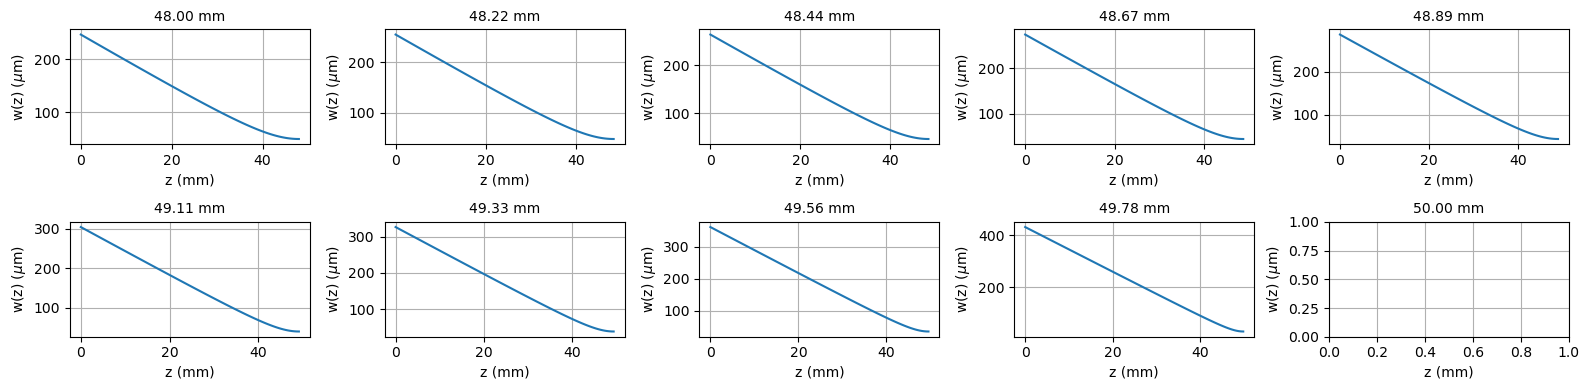

In [9]:
R1 = 50e-3   # radius of curvature concave mirror
wavelength = 780e-9     # m
wz_target = 40e-6   # 40 µm target waist

L_values = np.linspace(48e-3, 50e-3, 10)


plt.figure(figsize=(16,4))

for i, L in enumerate(L_values):
    waist_values, stability_values, wz_close, z_close, beam_profile, z_array = abcd.plan_concave( R1, np.array([L]), wavelength, wz_target, beam_profile=True)

    plt.subplot(2,5,i+1)

    if len(z_array) > 0 and len(beam_profile) > 0:      # condition to avoid empty arrays
        plt.plot(z_array[0]*1e3, beam_profile[0]*1e6)

    plt.title(f"{L*1e3:.2f} mm", fontsize=10)
    plt.xlabel("z (mm)")
    plt.ylabel(r"w(z) ($\mu$m)")
    plt.grid(True)

plt.tight_layout()
# plt.svefig("beam_profiles.png", dpi=300, bbox_inches='tight')

plt.show()